# Extracción de perfiles del International Multi-Tokamak Confinement Profile Database

In [1]:
import MDSplus
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Conection to database ITPA
conn = MDSplus.Connection('tokamak-profiledb.ccfe.ac.uk')
conn.openTree('pr08_t10', 47800)

In [3]:
# Measured profiles for n_e and T_e
Te = conn.get(r'\top.twod:te').data()
qe= conn.get(r'\top.twod:qeche').data()
ne = conn.get(r'\top.twod:ne').data()
B = conn.get(r'\top.zerod:bt')

In [4]:
t = conn.get(r'dim_of(\top.twod:te,1)').data()
rho = conn.get(r'dim_of(\top.twod:te,0)').data() 

In [5]:
Te_unit = conn.get(r'units_of(\top.twod:te)').data()
ne_unit = conn.get(r'units_of(\top.twod:ne)').data()
qe5_unit = conn.get(r'units_of(\top.twod:qeche)').data()
t_unit  = conn.get(r'units_of(dim_of(\top.twod:te,1))').data()
r_unit  = conn.get(r'units_of(dim_of(\top.twod:te,0))').data()

In [6]:
T = Te[1]
n = ne[1]
That = np.copy((T - T.min()) / (T.max() - T.min()))
nhat = np.copy((n - n.min()) / (n.max() - n.min()))

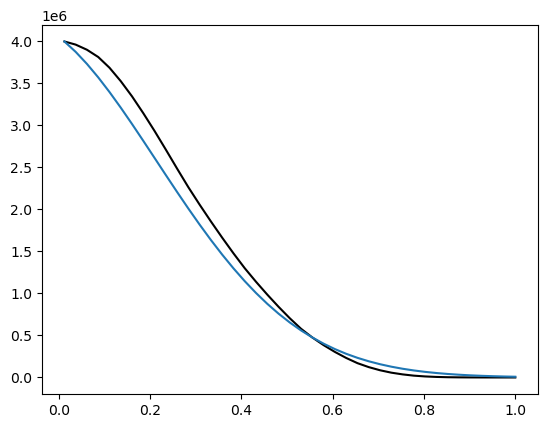

In [7]:
qhat = (qe[1] - qe[1].min()) / (qe[1].max() - qe[1].min())
s = 0.313
arr = np.exp(-0.5 * ((rho + 0.1) / s)**2) / (np.sqrt(2 * np.pi) * s)
arr *= (qe[1].max() / arr.max())
plt.plot(rho, qe[1], color="black")
plt.plot(rho, arr)

In [18]:
#def f(rho):
#    A1, mu1, s1 = 11.08561484, 0.09780836, 0.41682358
#    A2, mu2, s2 = 37.85138942, 0.49193007, 0.08961579
#    A3, mu3, s3 = 0.66483884, 0.87163258, 0.06679503
#    g = lambda A, mu, s: A * np.exp(-(rho - mu)**2 / (2 * s**2))
#    return (g(A1, mu1, s1) + g(A2, mu2, s2) + g(A3, mu3, s3)) * 6.24e12

#shat = np.copy((sum - sum.min()) / (sum.max() - sum.min()))
#sfit = f(rho)
#shat_fit = np.copy((sfit - sfit.min()) / (sfit.max() - sfit.min()))"""

In [8]:
import pandas as pd

dt = pd.read_csv('../data/profile/20260628124411.dat', sep=' ', header=None, comment='#')
tm = dt[2].to_numpy()
nm = dt[1].to_numpy()
rm = dt[0].to_numpy()

en = np.abs(nm - nhat)
et = np.abs(tm - That)

-0.014155230792320804

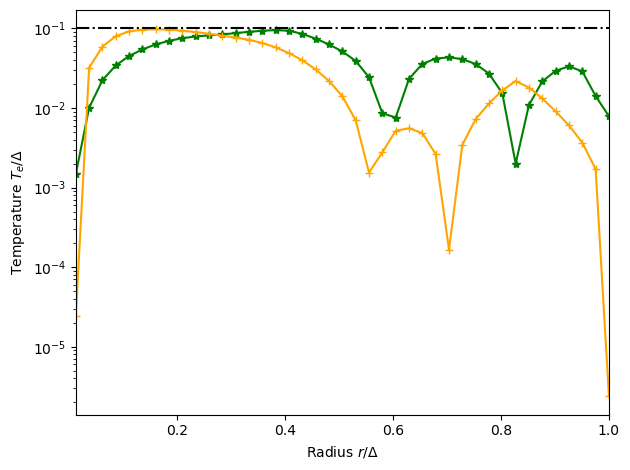

In [9]:
plt.figure()
plt.plot(rm, en, marker='*', linestyle='-', color='green')
plt.plot(rm, et, marker='+', linestyle='-', color='orange')
plt.plot(rm, np.ones_like(rm) * 0.1, linestyle='-.', color='black')
plt.xlim([rm.min(), rm.max()])
plt.yscale('log')
plt.xlabel(r"Radius $r / \Delta$")
plt.ylabel("Temperature $T_e / \Delta$")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
print(mean_absolute_error(tm, That))
print(np.sqrt(mean_squared_error(tm, That)))
print(np.abs(tm-That).max())
print(r2_score(tm, That))
print(r2_score(nm, nhat))
np.mean(tm - That)

0.03589580148741885
0.05039054474255754
0.09763938922834892
0.9745338058282265
0.9692557661348973


-0.03487244521712147

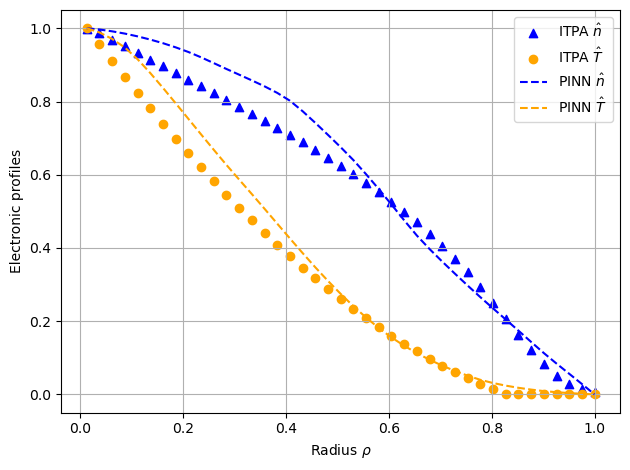

In [64]:
plt.figure()
plt.scatter(rm, nm, marker='^', color='blue', label=r"ITPA $\hat{n}$")
plt.scatter(rm, tm, marker='o', color='orange', label=r"ITPA $\hat{T}$")
plt.plot(rho, nhat, color='blue', linestyle='--', label=r"PINN $\hat{n}$")
plt.plot(rho, That, color='orange', linestyle='--', label=r'PINN $\hat{T}$')
plt.xlabel(r"Radius $\rho$")
plt.ylabel(f"Electronic profiles")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
with open("../data/profile/residualcurves.dat", "w") as f:
    for i in range(0, 40):
        print(rm[i], en[i], et[i], file=f, sep=' ')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def n_fit(x, a, b, c):
    return (1 - a) * (1 - x**2) ** b + a * np.sqrt(1 - c * x**2)

lower_bounds = [-np.inf, -np.inf, 0.0]  # Inferior cotes
upper_bounds = [ np.inf, np.inf, 1.0]  # Superior cotes

initial_guess = [0.4, 5.0, 0.5]
popt, pcov = curve_fit(n_fit, r, den, p0=initial_guess, bounds=(lower_bounds, upper_bounds), method='trf', absolute_sigma=True)
a_opt, b_opt, c_opt = popt
print(f"Fitted parameters:\na = {a_opt:.3f}\nb = {b_opt:.3f}\nc = {c_opt:.3f}")

plt.scatter(rho, nhat, color='blue', label='Experimental Data')
x_fit = np.linspace(0, 1, 40)
y_fit = n_fit(x_fit, *popt) 

plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fitted Formula Curve')
plt.xlabel(r'$\rho$')
plt.ylabel(r'Densidad $\hat{n}$')
plt.legend()
plt.show()

In [ ]:
with open("fit.dat", "w") as f:
    for i in range(40):
        print(x_fit[i], y_fit[i], file=f, sep=' ')

In [ ]:
def T_fit(x, a, b, c):
    return a * ( (x / 0.375)**b * np.exp(1 - (x / 0.375)**b))**c

lower_bounds = [0.0, 0.0, 0.0]  # Inferior cotes
upper_bounds = [ 1.0, np.inf, np.inf]  # Superior cotes

initial_guess = [1.0, 0.03, 1.0]
popt, pcov = curve_fit(T_fit, r, tmp, p0=initial_guess, bounds=(lower_bounds, upper_bounds), method='trf', absolute_sigma=True)
a_opt, b_opt, c_opt = popt
print(f"Fitted parameters:\na = {a_opt:.3f}\nb = {b_opt:.3f}\nc = {c_opt:.3f}")

plt.scatter(rho, That, color='blue', label='Experimental Data')
x_fit = np.linspace(0, 0.975, 40)
y_fit = T_fit(x_fit, *popt) 

plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fitted Formula Curve')
plt.xlabel(r'$\rho$')
plt.ylabel(r'Densidad $\hat{n}$')
plt.legend()
plt.show()